## Setup & load the dataset

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Load from Downloads — adjust path if on Windows: r"C:\Users\YourName\Downloads\..."
df = pd.read_csv("C:\\Users\\JUDITH\\Downloads\\dirty_ecommerce_dataset.csv")

# First look — you already know these from pandas work
print("Shape:", df.shape)
print("\nColumn dtypes:\n", df.dtypes)
display(df.head())

Shape: (1500, 13)

Column dtypes:
 order_id                int64
customer_name          object
email                  object
age                    object
gender                 object
country                object
signup_date            object
last_purchase_date     object
product                object
price                  object
quantity              float64
payment_method         object
phone                  object
dtype: object


,order_id,customer_name,email,age,gender,country,signup_date,last_purchase_date,product,price,quantity,payment_method,phone
0,27,Steven Walker,dicksonkevin@example.com,61,M,Germany,18/04/2015,26/01/1994,consider,abc,NaN,NaN,202.626.3026
1,51,Linda Singh,amberlewis@example.net,28,Male,UK,25/09/2013,06/07/1995,owner,NaN,NaN,Credit Card,+1-283-484-4443x96681
2,44,Jessica Ware,rvargas@example.org,NaN,M,NaN,03/12/1977,18/01/1995,far,NaN,NaN,Debit Card,not_available
3,3,Samuel Wilson,parkerjames@example.org,thirty,NaN,USA,02/04/2007,11/06/1988,activity,NaN,2.0,cash,+1-978-722-4317x15955
4,4,Eric Lopez,hwhite@example.org,60,Male,UK,21/12/2001,08/05/2017,war,abc,2.0,PayPal,not_available


## Missing values

=== MISSING VALUES ===


,missing_count,missing_%
age,493,32.87
price,352,23.47
quantity,330,22.00
payment_method,304,20.27
country,302,20.13
gender,279,18.60
customer_name,80,5.33


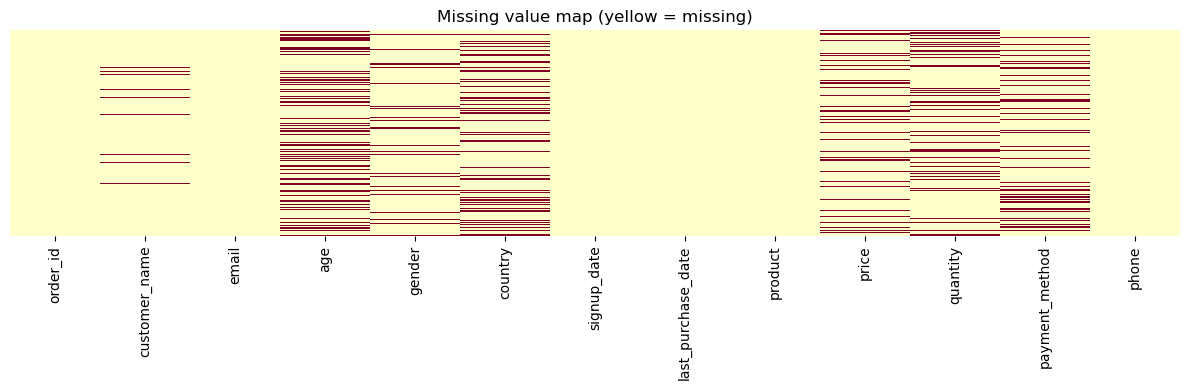

In [7]:
# --- Missing values ---
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_report = pd.DataFrame({
    "missing_count": missing,
    "missing_%": missing_pct
}).query("missing_count > 0").sort_values("missing_%", ascending=False)

print("=== MISSING VALUES ===")
display(missing_report)

# Visual — heatmap helps spot patterns (e.g. whole rows blank)
plt.figure(figsize=(12, 4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap="YlOrRd")
plt.title("Missing value map (yellow = missing)")
plt.tight_layout()
plt.show()

# Flag: add a boolean column per column with nulls
for col in missing_report.index:
    df[f"FLAG_missing_{col}"] = df[col].isnull()

## Duplicates

In [9]:
# --- Duplicates ---
n_dupes = df.duplicated().sum()
print(f"\n=== DUPLICATES ===\nFull duplicate rows: {n_dupes} ({n_dupes/len(df)*100:.2f}%)")

# Show the actual duplicate rows for inspection
if n_dupes > 0:
    display(df[df.duplicated(keep=False)].head(10))

# Flag duplicate rows
df["FLAG_duplicate_row"] = df.duplicated(keep=False)

# Column-level duplicates — e.g. order_id should be unique
id_cols = ["order_id", "customer_id"]  # adjust to your actual column names
for col in id_cols:
    if col in df.columns:
        duped = df[col].duplicated(keep=False)
        df[f"FLAG_duplicate_{col}"] = duped
        print(f"  Duplicate {col}: {duped.sum()} rows")


=== DUPLICATES ===
Full duplicate rows: 0 (0.00%)
  Duplicate order_id: 825 rows


## Data type inconsistencies

In [40]:
# --- Consolidated report ---
flag_cols = [c for c in df.columns if c.startswith("FLAG_")]

summary = []
for col in flag_cols:
    n_flagged = df[col].sum()
    pct = round(n_flagged / len(df) * 100, 2)
    summary.append({"flag": col, "rows_flagged": n_flagged, "pct_of_dataset": pct})

summary_df = pd.DataFrame(summary).sort_values("rows_flagged", ascending=False)

print("\n=== DATA QUALITY SUMMARY ===")
display(summary_df)

# Overall quality score (simple: % of rows that are clean across all flags)
any_issue = df[flag_cols].any(axis=1)
quality_score = round((1 - any_issue.mean()) * 100, 1)
print(f"\nOverall quality score: {quality_score}% rows have no flagged issues")

# Export flagged dataset
df.to_csv("~/Downloads/dirty_ecommerce_flagged.csv", index=False)
print("Flagged dataset saved.")


=== DATA QUALITY SUMMARY ===


,flag,rows_flagged,pct_of_dataset
11,FLAG_mixed_type_phone,1357,90.47
8,FLAG_duplicate_order_id,825,55.00
0,FLAG_missing_age,493,32.87
9,FLAG_mixed_type_age,488,32.53
10,FLAG_mixed_type_price,401,26.73
1,FLAG_missing_price,352,23.47
2,FLAG_missing_quantity,330,22.00
3,FLAG_missing_payment_method,304,20.27
4,FLAG_missing_country,302,20.13
13,FLAG_outlier_quantity,288,19.20



Overall quality score: 0.3% rows have no flagged issues
Flagged dataset saved.


## Outliers & value range issues

In [43]:
# --- Type inconsistencies ---
# Columns that look numeric but are stored as object (string)
print("\n=== TYPE CHECKS ===")

for col in df.select_dtypes(include="object").columns:
    # Try coercing to numeric — failures become NaN
    coerced = pd.to_numeric(df[col], errors="coerce")
    n_convertible = coerced.notna().sum()
    if n_convertible > 0 and n_convertible < len(df):  # mixed type
        df[f"FLAG_mixed_type_{col}"] = coerced.isna() & df[col].notna()
        print(f"  '{col}': {n_convertible} numeric values mixed with strings")

# Date columns — flag unparseable dates
date_cols = ["order_date", "ship_date"]  # adjust to your column names
for col in date_cols:
    if col in df.columns:
        parsed = pd.to_datetime(df[col], errors="coerce")
        bad_dates = parsed.isna() & df[col].notna()
        df[f"FLAG_invalid_date_{col}"] = bad_dates
        print(f"  '{col}': {bad_dates.sum()} unparseable dates")


=== TYPE CHECKS ===
  'age': 519 numeric values mixed with strings
  'price': 747 numeric values mixed with strings
  'phone': 143 numeric values mixed with strings


##  Summary report & quality score

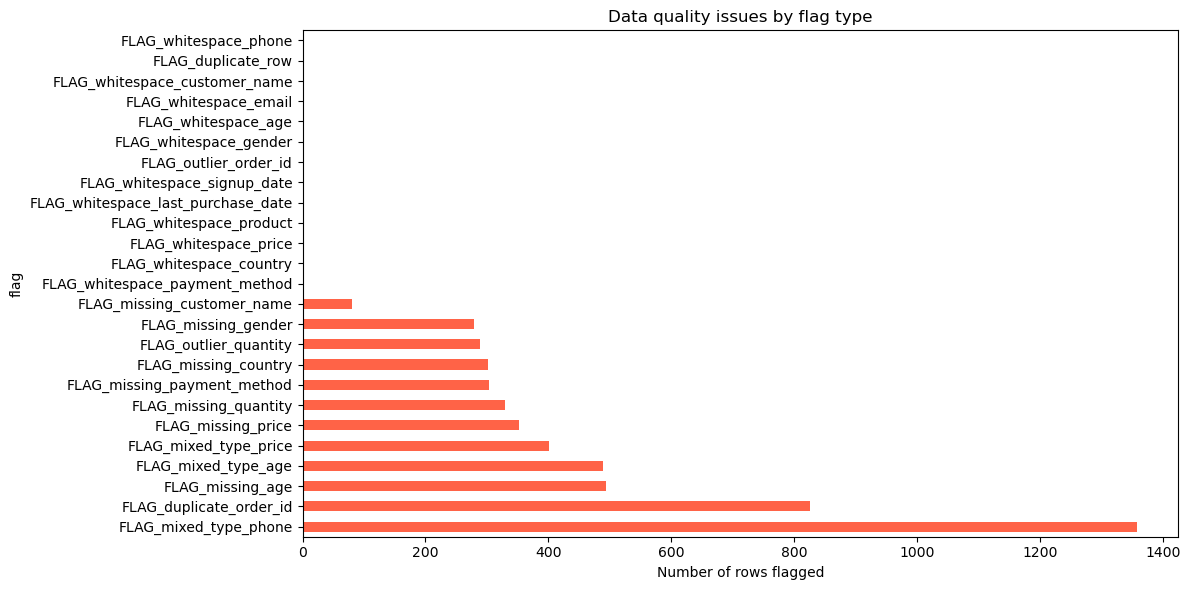

In [46]:
# Bar chart of flagged issue counts
plt.figure(figsize=(12, 6))
summary_df.set_index("flag")["rows_flagged"].plot(kind="barh", color="tomato")
plt.xlabel("Number of rows flagged")
plt.title("Data quality issues by flag type")
plt.tight_layout()
plt.show()